In [2]:
# crop_yield_prediction.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import joblib

In [3]:
# ===============================
# 1. Load Dataset
# ===============================
# Replace with your dataset path
data = pd.read_csv("crop_yield_dataset.csv")

print("Initial Data Shape:", data.shape)
print(data.head())

Initial Data Shape: (760, 12)
   Unnamed: 0       Crop  Crop_Year  Season   State      Area  Production  \
0           0  Arhar/Tur       1997  Autumn  Odisha   25621.0        6487   
1           1  Arhar/Tur       1997  Summer  Odisha   86559.0       16414   
2           2  Arhar/Tur       1997  Winter  Odisha  116553.0       23305   
3           3  Groundnut       1997  Autumn  Odisha   37462.0       34433   
4           4  Groundnut       1997  Summer  Odisha   39729.0       48815   

   Annual_Rainfall   Fertilizer  Pesticide     Yield  Temperature  
0           1496.6   2438350.57    7942.51  0.202778    21.890000  
1           1496.6   8237820.03   26833.29  0.216786    25.690000  
2           1496.6  11092349.01   36131.43  0.198929    19.876667  
3           1496.6   3565258.54   11613.22  0.840435    21.890000  
4           1496.6   3781008.93   12315.99  1.211071    25.690000  


In [4]:
# ===============================
# 2. Handle Missing Values
# ===============================
print("\nMissing values before handling:\n", data.isnull().sum())
data = data.dropna()   # or fillna() if needed
print("\nMissing values after handling:\n", data.isnull().sum())



Missing values before handling:
 Unnamed: 0         0
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Temperature        0
dtype: int64

Missing values after handling:
 Unnamed: 0         0
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Temperature        0
dtype: int64


In [5]:
# ===============================
# 3. Feature Engineering
# ===============================

# Drop index column if present
if data.columns[0] == "":
    data = data.drop(data.columns[0], axis=1)

# Encode categorical columns
categorical_cols = ["Crop", "Season", "State"]
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Feature-target split
X = data.drop("Yield", axis=1)
y = data["Yield"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# ===============================
# 4. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (608, 11) Test shape: (152, 11)


In [7]:
# ===============================
# 5. Model Training (Random Forest)
# ===============================
rf = RandomForestRegressor(
    n_estimators=300,       # number of trees
    max_depth=15,           # control overfitting
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# ===============================
# 6. Evaluation
# ===============================
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== Model Evaluation =====")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# Cross-validation for robust score
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring="r2")
print(f"\nCross-Validation R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



===== Model Evaluation =====
MAE:  1.3857
RMSE: 6.4002
R²:   0.6589

Cross-Validation R²: 0.9064 ± 0.0776

Cross-Validation R²: 0.9064 ± 0.0776


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Define parameter grid
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

# Fit
grid_search.fit(X_train, y_train)

# Best parameters
print("\nBest Parameters:", grid_search.best_params_)

# Best score
print("Best CV R² Score:", grid_search.best_score_)

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== Fine-Tuned Model Evaluation =====")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\jayan\Downloads\mlmodel\mymodel\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
720 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
322 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jayan\Downloads\mlmodel\mymodel\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jayan\Downloads\mlmodel\mymodel\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\jayan\Downloads\mlmodel\mymodel\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parame


Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV R² Score: 0.9519408550690402

===== Fine-Tuned Model Evaluation =====
MAE:  1.4912
RMSE: 5.7659
R²:   0.7231


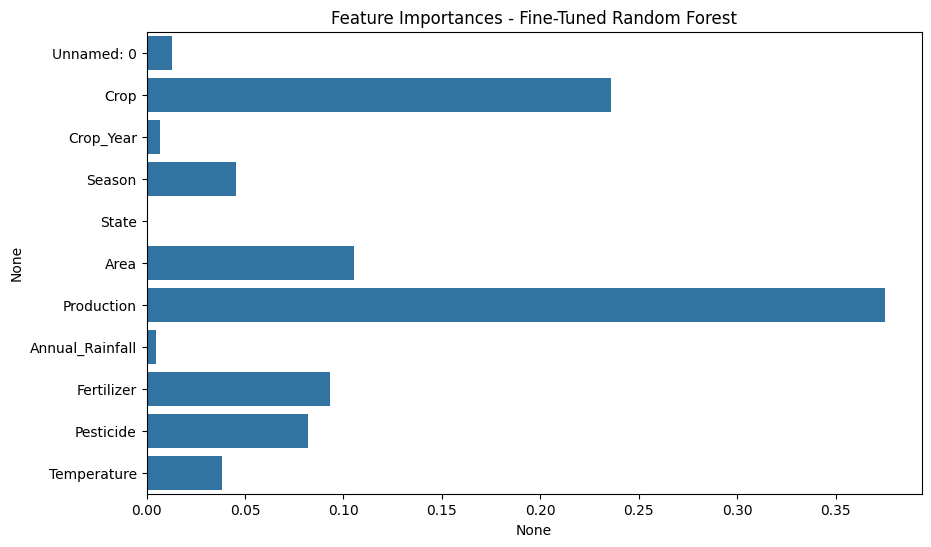

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the fine-tuned, fitted model
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature Importances - Fine-Tuned Random Forest")
plt.show()


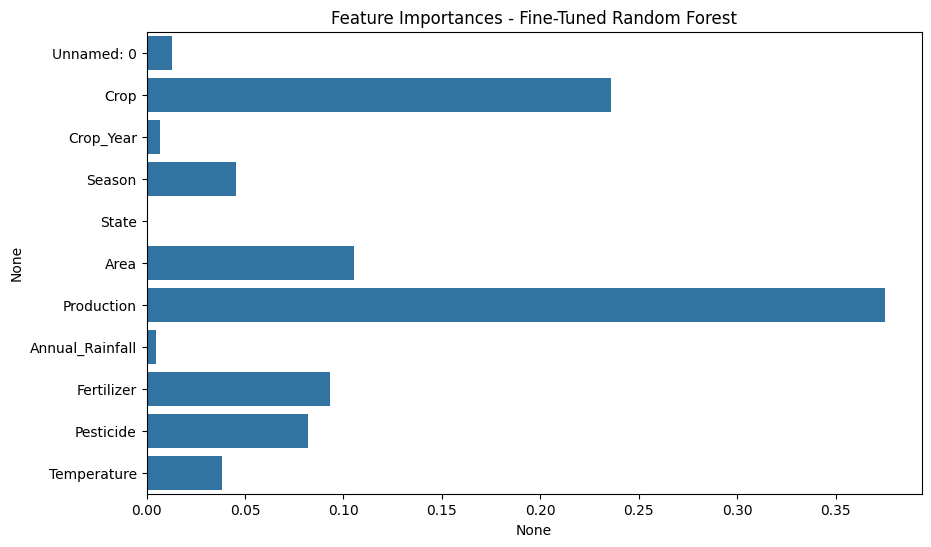

In [20]:
# ===============================
# 7. Feature Importance
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the fine-tuned, fitted model
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances, y=feat_importances.index)
plt.title("Feature Importances - Fine-Tuned Random Forest")
plt.show()


In [21]:
# ===============================
# 8. Save Model + Scaler
# ===============================
joblib.dump(rf, "crop_yield_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model and scaler saved as 'crop_yield_model.pkl' and 'scaler.pkl'")


✅ Model and scaler saved as 'crop_yield_model.pkl' and 'scaler.pkl'


In [9]:
# ===============================
# 9. Prepare for FastAPI Backend  
# ===============================

# First, let's save the model using the original rf model
print("Saving model and scaler for FastAPI...")

# Save the model and scaler
joblib.dump(rf, "crop_yield_model.pkl")  # Use the original rf model
joblib.dump(scaler, "scaler.pkl")

print("✅ Model and scaler saved successfully!")

# Create mappings for the API
import json

# Get the feature names after preprocessing  
feature_names = list(X.columns)
print(f"\nFeature order for API: {feature_names}")

# Get unique values for categorical variables (before encoding)
original_data = pd.read_csv("crop_yield_dataset.csv")

crops = sorted(original_data['Crop'].unique())
seasons = sorted(original_data['Season'].unique())
states = sorted(original_data['State'].unique())

# Create mappings (lowercase for API input)
crop_mapping = {crop.lower(): i for i, crop in enumerate(crops)}
season_mapping = {season.lower(): i for i, season in enumerate(seasons)}
state_mapping = {state.lower(): i for i, state in enumerate(states)}

print(f"\nCrop mapping: {crop_mapping}")
print(f"Season mapping: {season_mapping}") 
print(f"State mapping: {state_mapping}")

# Save mappings to file for API reference
mappings = {
    'feature_names': feature_names,
    'crop_mapping': crop_mapping,
    'season_mapping': season_mapping,
    'state_mapping': state_mapping
}

with open('api_mappings.json', 'w') as f:
    json.dump(mappings, f, indent=2)

print("\n✅ API mappings saved to 'api_mappings.json'")
print("🚀 Ready to start FastAPI server!")
print("\nTo start the server, run:")
print("  python -m uvicorn app:app --reload")
print("Then visit: http://localhost:8000/docs")

Saving model and scaler for FastAPI...
✅ Model and scaler saved successfully!

Feature order for API: ['Unnamed: 0', 'Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Temperature']

Crop mapping: {'arhar/tur': 0, 'bajra': 1, 'castor seed': 2, 'coriander': 3, 'cotton(lint)': 4, 'cowpea(lobia)': 5, 'dry chillies': 6, 'garlic': 7, 'ginger': 8, 'gram': 9, 'groundnut': 10, 'horse-gram': 11, 'jowar': 12, 'jute': 13, 'linseed': 14, 'maize': 15, 'masoor': 16, 'mesta': 17, 'moong(green gram)': 18, 'niger seed': 19, 'onion': 20, 'other  rabi pulses': 21, 'other kharif pulses': 22, 'peas & beans (pulses)': 23, 'potato': 24, 'ragi': 25, 'rapeseed &mustard': 26, 'rice': 27, 'safflower': 28, 'sannhamp': 29, 'sesamum': 30, 'small millets': 31, 'soyabean': 32, 'sugarcane': 33, 'sunflower': 34, 'sweet potato': 35, 'tobacco': 36, 'turmeric': 37, 'urad': 38, 'wheat': 39}
Season mapping: {'autumn': 0, 'kharif': 1, 'rabi': 2, 'summer': 3, 'whole ye